# [Weather Classification](https://www.kaggle.com/datasets/nikhil7280/weather-type-classification)

## Explication des variables
- Température (Temperature) : La température en degrés Celsius, allant de froid extrême à chaleur extrême.
- Humidité (Humidity) : Le pourcentage d’humidité.
- Vitesse du vent (Wind Speed) : La vitesse du vent en kilomètres par heure.
- Précipitations (Precipitation) : Le pourcentage de précipitations.
- Couverture nuageuse (Cloud Cover) : La description de la couverture nuageuse.
- Pression atmosphérique (Atmospheric Pressure) : La pression atmosphérique en hPa, couvrant une large plage de valeurs.
- Indice UV (UV Index) : L’indice UV, indiquant l’intensité du rayonnement ultraviolet.
- Saison (Season) : La saison durant laquelle les données ont été enregistrées.
- Visibilité (Visibility) : La visibilité en kilomètres, incluant des valeurs très faibles ou très élevées.
- Localisation (Location) : Le type de lieu où les données ont été enregistrées.
- Type de météo (Weather Type) : La variable cible pour la classification, indiquant le type de temps.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

### Chargement du dataset

In [4]:
# Chemin d'accès de la donnée
path = Path("weather_classification_data.csv")

# chargement du data set
data = pd.read_csv(path)
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


### Valeurs manquantes

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [6]:
data.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

> Le dataset contient 13200 observations et ne contient pas de valeurs manquantes. Il est constitué de données *numériques* et *catégorielles*

### Description statistique

Afin d’obtenir des statistiques descriptives pertinentes, les données ont été segmentées selon la saison et la localisation. En effet, les conditions météorologiques varient fortement selon ces deux dimensions, ce qui impacte directement les variables observées. Cette segmentation permet donc d’identifier des profils spécifiques et d’améliorer la compréhension des données.

In [13]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["Temperature"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean  median        std   min    max
Season Location                                           
Autumn coastal   25.476667    25.0  14.105297 -20.0   94.0
       inland    25.996222    26.0  13.667784 -18.0   97.0
       mountain  25.960298    26.0  13.980409 -20.0   99.0
Spring coastal   25.529279    25.0  14.124317 -20.0   99.0
       inland    25.941793    26.0  14.152478 -20.0  109.0
       mountain  25.468860    26.0  14.251189 -20.0   95.0
Summer coastal   26.178195    26.0  14.077290 -20.0   98.0
       inland    25.946903    26.0  14.336012 -20.0  108.0
       mountain  25.877358    26.0  13.756323 -19.0  107.0
Winter coastal   25.508602    25.0  14.558387 -19.0  107.0
       inland     7.416105     1.0  16.444279 -24.0   90.0
       mountain   6.607452     1.0  15.989978 -25.0   97.0

In [14]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["Humidity"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean  median        std  min  max
Season Location                                        
Autumn coastal   65.796667    67.0  20.210125   20  109
       inland    64.250630    65.0  20.968093   20  109
       mountain  64.069479    66.0  20.689365   20  109
Spring coastal   65.431306    66.0  20.341609   20  109
       inland    63.813737    65.0  21.054990   20  109
       mountain  64.681551    66.0  20.322943   20  109
Summer coastal   64.994138    67.0  20.337094   20  109
       inland    66.590392    68.0  20.801512   20  109
       mountain  65.094340    65.0  20.335104   20  109
Winter coastal   65.054839    66.0  20.591527   20  109
       inland    75.779511    77.0  17.754758   20  109
       mountain  75.210139    76.0  17.398428   20  109

In [15]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["Wind Speed"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean  median       std  min   max
Season Location                                        
Autumn coastal    9.538889     8.5  6.304574  0.0  47.5
       inland     9.585013     8.5  6.675982  0.0  44.0
       mountain   9.536600     8.0  7.205215  0.0  47.0
Spring coastal    9.368806     8.5  6.195151  0.0  44.5
       inland     9.056461     8.0  6.590990  0.0  43.5
       mountain   9.015864     8.0  6.244766  0.0  39.0
Summer coastal    9.706331     8.5  6.647980  0.0  47.0
       inland     9.706068     8.5  6.846131  0.0  41.5
       mountain   9.378538     8.5  6.460212  0.0  43.0
Winter coastal    9.495161     8.5  6.585549  0.0  45.0
       inland    10.733558     9.5  7.504030  0.0  46.5
       mountain  10.368718     9.0  7.344936  0.0  48.5

In [16]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["Precipitation (%)"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean  median        std  min    max
Season Location                                          
Autumn coastal   47.925556    45.0  32.249169  0.0  109.0
       inland    46.285894    42.0  32.341535  0.0  109.0
       mountain  46.848635    41.0  33.538770  0.0  109.0
Spring coastal   48.087838    45.0  32.520970  0.0  109.0
       inland    45.850990    42.0  31.966163  0.0  109.0
       mountain  45.142186    39.0  32.623770  0.0  109.0
Summer coastal   46.420868    40.0  32.604471  0.0  109.0
       inland    48.978508    48.0  32.327529  0.0  109.0
       mountain  46.161557    43.0  32.523080  0.0  109.0
Winter coastal   48.144086    47.0  32.171310  0.0  109.0
       inland    65.563659    72.0  27.260768  0.0  109.0
       mountain  65.937175    72.0  26.796993  0.0  109.0

In [17]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["Atmospheric Pressure"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean    median        std     min      max
Season Location                                                   
Autumn coastal   1012.267311  1013.180  42.756332  804.51  1197.92
       inland    1011.400453  1012.000  37.712118  802.47  1198.41
       mountain  1008.852345  1013.470  41.457827  800.83  1180.39
Spring coastal   1010.937061  1012.110  41.582377  800.23  1197.20
       inland    1011.003877  1012.220  44.058277  803.81  1194.98
       mountain  1010.030987  1012.780  45.402375  803.02  1199.21
Summer coastal   1010.431149  1011.740  38.021809  805.58  1198.85
       inland    1010.259924  1012.550  37.886202  803.29  1194.59
       mountain  1008.176486  1012.510  40.107875  800.82  1196.03
Winter coastal   1009.936366  1011.840  41.042238  800.12  1196.00
       inland     997.988642   994.555  27.930993  803.84  1194.57
       mountain   997.219662   994.395  25.622444  806.42  1197.04

In [18]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["UV Index"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean  median       std  min  max
Season Location                                      
Autumn coastal   4.655556     3.0  3.701490    0   14
       inland    4.841310     3.0  3.730182    0   14
       mountain  4.849876     4.0  3.774520    0   14
Spring coastal   4.793919     4.0  3.754184    0   14
       inland    4.760186     4.0  3.677659    0   14
       mountain  4.813161     4.0  3.775352    0   14
Summer coastal   4.815944     3.0  3.893853    0   14
       inland    4.905183     3.0  3.923298    0   14
       mountain  4.844340     4.0  3.837221    0   14
Winter coastal   4.640860     3.0  3.836268    0   14
       inland    2.696037     1.0  3.656130    0   14
       mountain  2.462738     1.0  3.453687    0   14

In [19]:
# Groupement par Season et Location
stats = data.groupby(["Season", "Location"])["Visibility (km)"].agg(
    ["mean", "median", "std", "min", "max"]
)

# Affichage
stats

mean  median       std  min   max
Season Location                                       
Autumn coastal   6.248889     6.0  3.481598  0.0  19.5
       inland    6.219773     6.0  3.414031  0.0  20.0
       mountain  6.401985     6.0  3.567583  0.0  19.5
Spring coastal   6.049550     6.0  3.458617  0.0  20.0
       inland    6.288708     6.5  3.380735  0.0  20.0
       mountain  6.398355     6.5  3.492843  0.0  19.5
Summer coastal   6.258499     6.0  3.445033  0.0  20.0
       inland    5.986726     6.0  3.446170  0.0  20.0
       mountain  6.251179     6.5  3.269479  0.0  19.5
Winter coastal   5.915054     5.5  3.428775  0.0  20.0
       inland    4.163786     3.5  2.821568  0.0  20.0
       mountain  4.079939     3.5  2.735683  0.0  19.5

> L’analyse met en évidence que la saison est le principal facteur influençant les conditions météorologiques. Les variables restent globalement
> stables sur l’année, mais des variations significatives apparaissent en hiver, notamment dans les zones inland et montagneuses. Ces zones se
> caractérisent par des températures plus basses, une humidité et des précipitations plus élevées, une pression atmosphérique plus faible ainsi qu’une
> visibilité réduite. À l’inverse, les zones côtières présentent des conditions plus stables, suggérant un effet modérateur du climat maritime.

### Détections d'anomalie

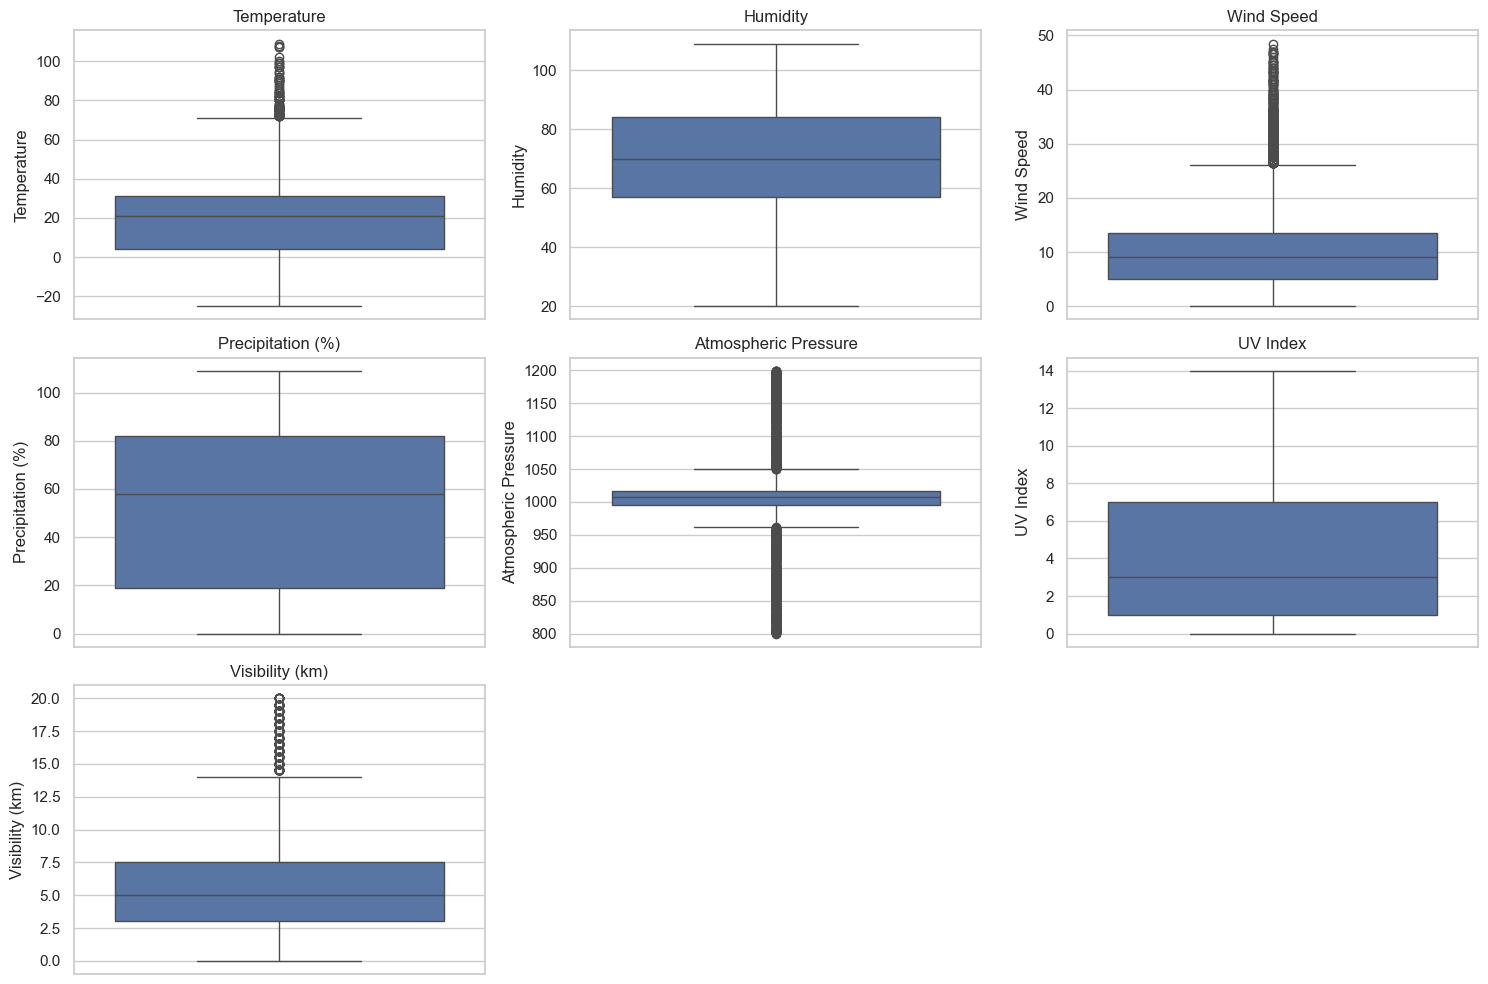

In [20]:
sns.set(style="whitegrid")

# Variables numériques
num_cols = [
    "Temperature",
    "Humidity",
    "Wind Speed",
    "Precipitation (%)",
    "Atmospheric Pressure",
    "UV Index",
    "Visibility (km)"
]

# Taille du graphique
plt.figure(figsize=(15, 10))

# Boucle pour afficher chaque variable
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

>L’analyse des boxplots met en évidence la présence de valeurs extrêmes dans plusieurs variables. Il est important de distinguer les valeurs aberrantes, qui correspondent à des observations rares mais plausibles, des anomalies, qui sont des valeurs incohérentes, physiquement impossibles voire irréalistes.
>  - La température présente plusieurs valeurs extrêmes très élevées, considérées comme des anomalies car irréalistes dans un contexte météorologique. Les valeurs basses restent plausibles.
>  - L’humidité présente des valeurs supérieures à 100%, ce qui constitue des anomalies (physiquement impossibles). Le reste de la distribution est cohérent.
>  - La vitesse du vent montre une dispersion modérée avec des valeurs élevées. Ces dernières peuvent être considérées comme des valeurs aberrantes mais restent plausibles dans certaines conditions météorologiques.
>  - Les précipitations présentent une forte variabilité. Les valeurs supérieures à 100% sont des anomalies, tandis que la dispersion globale reflète une variabilité naturelle du phénomène.
>  - La pression est globalement stable mais contient de nombreuses valeurs extrêmes. Les valeurs très basses ou très élevées sont considérées comme des anomalies, car incohérentes avec les plages normales.
>  - L’indice UV présente une distribution cohérente sans anomalies. Les valeurs élevées correspondent à des situations réalistes.
>  - La visibilité présente quelques valeurs élevées, considérées comme des valeurs aberrantes, mais plausibles dans des conditions très favorables.

### Insights / Observations

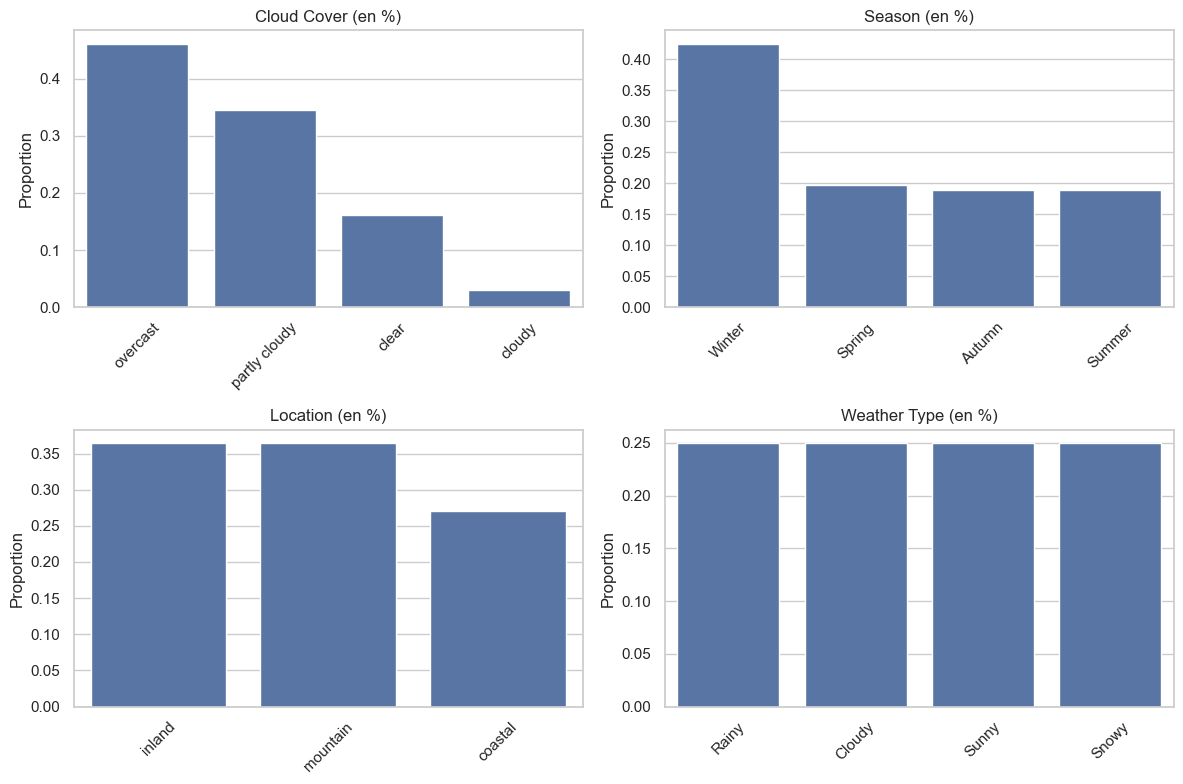

In [27]:
cat_cols = ["Cloud Cover", "Season", "Location", "Weather Type"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    
    proportions = data[col].value_counts(normalize=True)
    
    sns.barplot(
        x=proportions.index,
        y=proportions.values
    )
    
    plt.title(f"{col} (en %)")
    plt.ylabel("Proportion")
    plt.xlabel("")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> La variable cible est équilibrée, ce qui constitue un avantage pour l’apprentissage des modèles de classification. Aucune technique de rééquilibrage
> n’est nécessaire. Toutefois, certaines variables explicatives présentent des déséquilibres, qui devront être pris en compte dans l’analyse.